# Lab: Data exploration

---

<a id="learning-objectives"></a>
## Learning Objectives
*After completing this lab, you will be able to:*

- Explore and interrogate different data sets using our pandas and matplotlib.
- Interpret the findings to understand what the data tells us about the real world.

<a id="coffee"></a>

# <font color='blue'> Coffee shop data</font>

## Part A

In this Lab we'll be working with one datasets.
    
The dataset consists of coffee shop transactions, a dataset created by IBM and made available on [Kaggle](https://www.kaggle.com/datasets/ylchang/coffee-shop-sample-data-1113).

The data consists of coffee shop transactions in April 2019.

There are ~50,000 total transactions in the data set. The data consists of transactions from shops in New York City only.

Our task is to answer 3 questions:
1. **Which products offer the best margins?**
2. **Are particular customer groups spending more?**
3. **Which products generate the most sales?**

<br />

Let's start by reading in the data as a pandas `DataFrame` called `coffee_df`.

In [134]:
# Importing needed library
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

##### 1.❓ Next, let's read in the data as a pandas `DataFrame` called `coffee_df`

In [135]:
coffee = pd.read_csv('./data/coffee_shop_lab.csv')

##### 2.❓Now preview the first 5 rows of the data.

In [136]:
coffee.head()

,transaction_date,transaction_time,customer_id,quantity,line_item_amount,unit_price,product_group,product_category,product_type,current_wholesale_price,customer_since,customer_birth_year,customer_generation
0,2019-04-01,12:04:43,558.0,1,2.5,2.5,Beverages,Tea,Brewed Chai tea,0.63,2018-06-19,1983.0,Older Millennials
1,2019-04-01,11:15:38,22.0,1,2.5,2.5,Beverages,Tea,Brewed Chai tea,0.63,2017-03-03,1953.0,Baby Boomers
2,2019-04-01,12:05:31,659.0,2,5.0,2.5,Beverages,Tea,Brewed Chai tea,0.63,2019-01-14,1996.0,Gen Z
3,2019-04-01,16:49:38,407.0,1,2.5,2.5,Beverages,Tea,Brewed Chai tea,0.63,2017-08-11,1963.0,Baby Boomers
4,2019-04-01,19:17:34,537.0,2,5.0,2.5,Beverages,Tea,Brewed Chai tea,0.63,2018-05-06,1980.0,Older Millennials


##### 3.❓ How many rows and columns does the dataset have?

In [137]:
coffee.shape


(49894, 13)

##### 4.❓ Check the type of data in each column- do you notice any problems?

In [138]:
coffee.info()


<class 'pandas.DataFrame'>
RangeIndex: 49894 entries, 0 to 49893
Data columns (total 13 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   transaction_date         49894 non-null  str    
 1   transaction_time         49894 non-null  str    
 2   customer_id              24861 non-null  float64
 3   quantity                 49894 non-null  int64  
 4   line_item_amount         49894 non-null  float64
 5   unit_price               49894 non-null  float64
 6   product_group            49894 non-null  str    
 7   product_category         49894 non-null  str    
 8   product_type             49894 non-null  str    
 9   current_wholesale_price  49894 non-null  float64
 10  customer_since           24852 non-null  str    
 11  customer_birth_year      24852 non-null  float64
 12  customer_generation      24852 non-null  str    
dtypes: float64(5), int64(1), str(7)
memory usage: 7.7 MB


> 👉 **Write Your Findings Here**: 
--
> - trasaction date is a string
> - customer birth date is a string
> - customer since is a string

##### 5.❓ You might have noticed earlier when running the `dtypes` command that the `transaction_date` and `customer_since` columns are currently being treated like strings. We need to convert them into date columns so we can calculate factors like how long someone's been a customer.

Try using pd.to_datetime() to convert these two columns to date representations

In [139]:
coffee['transaction_date']=pd.to_datetime(coffee['transaction_date'])
coffee['customer_since']=pd.to_datetime(coffee['customer_since'])
coffee.dtypes

transaction_date           datetime64[us]
transaction_time                      str
customer_id                       float64
quantity                            int64
line_item_amount                  float64
unit_price                        float64
product_group                         str
product_category                      str
product_type                          str
current_wholesale_price           float64
customer_since             datetime64[us]
customer_birth_year               float64
customer_generation                   str
dtype: object

##### 6.❓ Examine the percentage of missing values in each column. What might these missing values represent? How would you suggest handling them?



In [140]:
coffee.isnull().mean()*100


transaction_date            0.000000
transaction_time            0.000000
customer_id                50.172365
quantity                    0.000000
line_item_amount            0.000000
unit_price                  0.000000
product_group               0.000000
product_category            0.000000
product_type                0.000000
current_wholesale_price     0.000000
customer_since             50.190404
customer_birth_year        50.190404
customer_generation        50.190404
dtype: float64

👉 Since more than 50% of the customer-related data is missing

👉 The missing values in the customer-related columns of your coffee dataset could represent:

- Guest Customers 
- Incomplete Data Collection 
- Data Integration Issues
  

👉 Is the missing values essentials to your analysis? 
- If necessary:
    - consider finding the missing values
    - Or, create a dataset that contains the rows that have filled information and discard the rows that have null values for that customer-related columns.

- If not necessary in your analysis, just ignore them

##### 7.❓ Check for duplicate values, and remove them if any.

In [141]:
# how many duplicates we have
coffee.duplicated().sum()


np.int64(149)

In [142]:
# Remove the duplicates and check if the total duplicates is 0 now
coffee_d = coffee.drop_duplicates()
coffee_d.duplicated().sum()

np.int64(0)

##### 8.❓ Explore the unique values in all the categorical columns:
- product group
- product category
- product type
- customer_generation

1. What inconsistencies do you notice?
2. Is there a spelling consistency?
3. Do you need to fix anything?

In [143]:
# unique values in product group
coffee['product_group'].unique()


<ArrowStringArray>
['Beverages', 'Food', 'Whole Bean/Teas', 'Add-ons', 'Merchandise']
Length: 5, dtype: str

In [144]:
# unique values in product category
coffee['product_category'].unique()



<ArrowStringArray>
[               'Tea',             'Coffee', 'Drinking Chocolate',
             'Bakery',       'Coffee beans',           'Flavours',
          'Loose Tea', 'Packaged Chocolate',            'Branded']
Length: 9, dtype: str

In [145]:
# unique values in product type
coffee['product_type'].unique()



<ArrowStringArray>
[      'Brewed Chai tea', 'Organic brewed coffee',      'Brewed Green tea',
           'Drip coffee', 'Premium brewed coffee', 'Gourmet brewed coffee',
      'Brewed Black tea',         'Hot chocolate',      'Barista Espresso',
                 'Scone',     'Brewed herbal tea',              'Biscotti',
                'Pastry',         'Organic Beans',         'Regular syrup',
            'Herbal tea',         'Gourmet Beans',             'Black tea',
      'Sugar free syrup',     'House blend Beans',         'Premium Beans',
              'Chai tea',     'Organic Chocolate',    'Drinking Chocolate',
           'Green beans',             'Green tea',        'Espresso Beans',
            'Housewares',              'Clothing']
Length: 29, dtype: str

In [146]:
# unique values in customer_generation

coffee['customer_generation'] = coffee['customer_generation'].fillna('unknown')
coffee['customer_generation'].unique()

<ArrowStringArray>
[  'Older Millennials',        'Baby Boomers',               'Gen Z',
               'Gen X', 'Younger Millennials',             'unknown']
Length: 6, dtype: str

##### 9.❓The `describe()` method is a handy way of accessing summary statistics for an entire `DataFrame` in one go. Try running it on your `DataFrame`:


In [147]:
coffee.describe()


,transaction_date,customer_id,quantity,line_item_amount,unit_price,current_wholesale_price,customer_since,customer_birth_year
count,49894,24861.000000,49894.000000,49894.000000,49894.000000,49894.000000,24852,24852.000000
mean,2019-04-15 01:16:35.855213,4580.439122,1.438209,4.682646,3.384645,1.356443,2018-02-21 05:28:56.552390,1978.252455
min,2019-04-01 00:00:00,1.000000,1.000000,0.000000,0.800000,0.040000,2017-01-03 00:00:00,1950.000000
25%,2019-04-08 00:00:00,584.000000,1.000000,3.000000,2.500000,0.600000,2017-08-05 00:00:00,1965.000000
50%,2019-04-15 00:00:00,5417.000000,1.000000,3.750000,3.000000,0.750000,2018-02-22 00:00:00,1981.000000
75%,2019-04-22 00:00:00,8099.000000,2.000000,6.000000,3.750000,1.950000,2018-09-16 00:00:00,1992.000000
max,2019-04-29 00:00:00,8501.000000,8.000000,360.000000,45.000000,36.000000,2019-04-09 00:00:00,2001.000000
std,NaN,3247.865616,0.543039,4.436668,2.682545,2.201801,NaN,15.091661


##### 10.❓What is your findings about the above summery statistics?

> Write your findings here:

👉 The `line_item_amount` column has a minimum value of 0, which seems unusual. This could indicate potential error values.

👉 The quantity column appears to be right-skewed, with 75% of orders containing only two products, while the maximum quantity is 8.

- Let's start to clean up our dataset and answer the questions in our analysis.

- We have the total line item amount (the retail price) as well as the wholesale price of the product.

- We want to calculate the **total wholesale line item amount** so we can use it to calculate profit.

##### 11.❓Can you combine the existing wholesale amount and quantity columns to create a new column in the `DataFrame` called `total_wholesale_amount` which holds the new values?

In [148]:

coffee['total_wholesale_amount'] = coffee['quantity'] * coffee['current_wholesale_price']
coffee.head()

,transaction_date,transaction_time,customer_id,quantity,line_item_amount,unit_price,product_group,product_category,product_type,current_wholesale_price,customer_since,customer_birth_year,customer_generation,total_wholesale_amount
0,2019-04-01,12:04:43,558.0,1,2.5,2.5,Beverages,Tea,Brewed Chai tea,0.63,2018-06-19,1983.0,Older Millennials,0.63
1,2019-04-01,11:15:38,22.0,1,2.5,2.5,Beverages,Tea,Brewed Chai tea,0.63,2017-03-03,1953.0,Baby Boomers,0.63
2,2019-04-01,12:05:31,659.0,2,5.0,2.5,Beverages,Tea,Brewed Chai tea,0.63,2019-01-14,1996.0,Gen Z,1.26
3,2019-04-01,16:49:38,407.0,1,2.5,2.5,Beverages,Tea,Brewed Chai tea,0.63,2017-08-11,1963.0,Baby Boomers,0.63
4,2019-04-01,19:17:34,537.0,2,5.0,2.5,Beverages,Tea,Brewed Chai tea,0.63,2018-05-06,1980.0,Older Millennials,1.26


##### 12.❓Can you now create a new column called `profit` which shows the difference between the wholesale price and retail price(line_item_amount)?

In [149]:
coffee['profit'] = coffee['line_item_amount'] - coffee['current_wholesale_price']
coffee.head()

,transaction_date,transaction_time,customer_id,quantity,line_item_amount,unit_price,product_group,product_category,product_type,current_wholesale_price,customer_since,customer_birth_year,customer_generation,total_wholesale_amount,profit
0,2019-04-01,12:04:43,558.0,1,2.5,2.5,Beverages,Tea,Brewed Chai tea,0.63,2018-06-19,1983.0,Older Millennials,0.63,1.87
1,2019-04-01,11:15:38,22.0,1,2.5,2.5,Beverages,Tea,Brewed Chai tea,0.63,2017-03-03,1953.0,Baby Boomers,0.63,1.87
2,2019-04-01,12:05:31,659.0,2,5.0,2.5,Beverages,Tea,Brewed Chai tea,0.63,2019-01-14,1996.0,Gen Z,1.26,4.37
3,2019-04-01,16:49:38,407.0,1,2.5,2.5,Beverages,Tea,Brewed Chai tea,0.63,2017-08-11,1963.0,Baby Boomers,0.63,1.87
4,2019-04-01,19:17:34,537.0,2,5.0,2.5,Beverages,Tea,Brewed Chai tea,0.63,2018-05-06,1980.0,Older Millennials,1.26,4.37


##### 13.❓Find the highest sale price in the dataset.

In [150]:
coffee['current_wholesale_price'].max()


np.float64(36.0)

##### 14.❓Find the largest amount of profit.

In [151]:
coffee['profit'].max()


np.float64(324.0)

The largest profit is significant - but it's obviously not representative of how much profit is made on each transaction on average.

##### 15.❓Find the mean of all the profit.

In [152]:
coffee['profit'].mean()



np.float64(3.3262027498296387)

##### 16.❓Now, let's start filtering our data by writing logical tests. How many transactions were valued above the **mean** transaction amount?

In [153]:
coffee[
    coffee['total_wholesale_amount'] > coffee['total_wholesale_amount'].mean()
]


,transaction_date,transaction_time,customer_id,quantity,line_item_amount,unit_price,product_group,product_category,product_type,current_wholesale_price,customer_since,customer_birth_year,customer_generation,total_wholesale_amount,profit
515,2019-04-15,08:12:42,5652.0,3,7.50,2.50,Beverages,Tea,Brewed Chai tea,0.63,2018-08-31,1987.0,Older Millennials,1.89,6.87
673,2019-04-20,07:45:35,NaN,3,7.50,2.50,Beverages,Tea,Brewed Chai tea,0.63,NaT,NaN,unknown,1.89,6.87
678,2019-04-20,16:10:25,NaN,3,7.50,2.50,Beverages,Tea,Brewed Chai tea,0.63,NaT,NaN,unknown,1.89,6.87
712,2019-04-21,14:39:37,NaN,3,7.50,2.50,Beverages,Tea,Brewed Chai tea,0.63,NaT,NaN,unknown,1.89,6.87
714,2019-04-21,17:41:59,NaN,3,7.50,2.50,Beverages,Tea,Brewed Chai tea,0.63,NaT,NaN,unknown,1.89,6.87
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
49889,2019-04-24,09:31:54,8113.0,1,8.95,8.95,Whole Bean/Teas,Loose Tea,Herbal tea,7.16,2017-01-08,1998.0,Gen Z,7.16,1.79
49890,2019-04-25,06:17:12,5778.0,1,8.95,8.95,Whole Bean/Teas,Loose Tea,Herbal tea,7.16,2017-04-08,1956.0,Baby Boomers,7.16,1.79
49891,2019-04-25,10:48:21,NaN,1,8.95,8.95,Whole Bean/Teas,Loose Tea,Herbal tea,7.16,NaT,NaN,unknown,7.16,1.79
49892,2019-04-25,08:54:27,8039.0,1,8.95,8.95,Whole Bean/Teas,Loose Tea,Herbal tea,7.16,2017-06-26,1963.0,Baby Boomers,7.16,1.79


##### 17.❓Create a new column called `profit_ratio` which shows the ratio between the wholesale and retail prices.

In [154]:
coffee['profit_ratio'] = coffee['line_item_amount'] / coffee['total_wholesale_amount']

coffee.tail()

,transaction_date,transaction_time,customer_id,quantity,line_item_amount,unit_price,product_group,product_category,product_type,current_wholesale_price,customer_since,customer_birth_year,customer_generation,total_wholesale_amount,profit,profit_ratio
49889,2019-04-24,09:31:54,8113.0,1,8.95,8.95,Whole Bean/Teas,Loose Tea,Herbal tea,7.16,2017-01-08,1998.0,Gen Z,7.16,1.79,1.25
49890,2019-04-25,06:17:12,5778.0,1,8.95,8.95,Whole Bean/Teas,Loose Tea,Herbal tea,7.16,2017-04-08,1956.0,Baby Boomers,7.16,1.79,1.25
49891,2019-04-25,10:48:21,NaN,1,8.95,8.95,Whole Bean/Teas,Loose Tea,Herbal tea,7.16,NaT,NaN,unknown,7.16,1.79,1.25
49892,2019-04-25,08:54:27,8039.0,1,8.95,8.95,Whole Bean/Teas,Loose Tea,Herbal tea,7.16,2017-06-26,1963.0,Baby Boomers,7.16,1.79,1.25
49893,2019-04-25,14:32:27,8081.0,1,8.95,8.95,Whole Bean/Teas,Loose Tea,Herbal tea,7.16,2017-06-29,1980.0,Older Millennials,7.16,1.79,1.25


##### 18.❓Based on profit ratio, How many transactions made a profit of at least 2 times their wholesale cost?

In [155]:
coffee[
    coffee['profit_ratio'] >=  2
]

,transaction_date,transaction_time,customer_id,quantity,line_item_amount,unit_price,product_group,product_category,product_type,current_wholesale_price,customer_since,customer_birth_year,customer_generation,total_wholesale_amount,profit,profit_ratio
0,2019-04-01,12:04:43,558.0,1,2.5,2.5,Beverages,Tea,Brewed Chai tea,0.63,2018-06-19,1983.0,Older Millennials,0.63,1.87,3.968254
1,2019-04-01,11:15:38,22.0,1,2.5,2.5,Beverages,Tea,Brewed Chai tea,0.63,2017-03-03,1953.0,Baby Boomers,0.63,1.87,3.968254
2,2019-04-01,12:05:31,659.0,2,5.0,2.5,Beverages,Tea,Brewed Chai tea,0.63,2019-01-14,1996.0,Gen Z,1.26,4.37,3.968254
3,2019-04-01,16:49:38,407.0,1,2.5,2.5,Beverages,Tea,Brewed Chai tea,0.63,2017-08-11,1963.0,Baby Boomers,0.63,1.87,3.968254
4,2019-04-01,19:17:34,537.0,2,5.0,2.5,Beverages,Tea,Brewed Chai tea,0.63,2018-05-06,1980.0,Older Millennials,1.26,4.37,3.968254
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
49835,2019-04-26,07:35:47,NaN,1,14.0,14.0,Merchandise,Branded,Housewares,4.48,NaT,NaN,unknown,4.48,9.52,3.125000
49836,2019-04-26,08:06:19,5199.0,1,14.0,14.0,Merchandise,Branded,Housewares,4.48,2018-07-27,1994.0,Younger Millennials,4.48,9.52,3.125000
49837,2019-04-26,06:59:38,5072.0,1,14.0,14.0,Merchandise,Branded,Housewares,4.48,2017-03-02,1981.0,Older Millennials,4.48,9.52,3.125000
49838,2019-04-26,11:33:51,NaN,1,14.0,14.0,Merchandise,Branded,Housewares,4.48,NaT,NaN,unknown,4.48,9.52,3.125000


##### 19.❓How many transactions in the dataset were for coffee `beans`? You'll have to think creatively about where this information is stored in the dataset, and how to extract it.

In [156]:
coffee[
    coffee['product_category'] == 'Coffee beans'
    ]


,transaction_date,transaction_time,customer_id,quantity,line_item_amount,unit_price,product_group,product_category,product_type,current_wholesale_price,customer_since,customer_birth_year,customer_generation,total_wholesale_amount,profit,profit_ratio
46262,2019-04-07,09:59:06,NaN,1,28.0,28.0,Whole Bean/Teas,Coffee beans,Organic Beans,18.0,NaT,NaN,unknown,18.0,10.0,1.555556
46263,2019-04-07,09:27:50,5598.0,1,23.0,23.0,Whole Bean/Teas,Coffee beans,Organic Beans,18.0,2017-11-22,1988.0,Older Millennials,18.0,5.0,1.277778
46264,2019-04-07,09:25:31,5494.0,1,23.0,23.0,Whole Bean/Teas,Coffee beans,Organic Beans,18.0,2018-11-29,1993.0,Younger Millennials,18.0,5.0,1.277778
46265,2019-04-07,09:05:19,5598.0,1,28.0,28.0,Whole Bean/Teas,Coffee beans,Organic Beans,18.0,2017-11-22,1988.0,Older Millennials,18.0,10.0,1.555556
46266,2019-04-07,07:50:42,NaN,1,28.0,28.0,Whole Bean/Teas,Coffee beans,Organic Beans,18.0,NaT,NaN,unknown,18.0,10.0,1.555556
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
49659,2019-04-25,10:44:34,8413.0,1,15.0,15.0,Whole Bean/Teas,Coffee beans,Gourmet Beans,12.0,2018-11-17,1994.0,Younger Millennials,12.0,3.0,1.250000
49660,2019-04-26,16:46:17,NaN,1,15.0,15.0,Whole Bean/Teas,Coffee beans,Gourmet Beans,12.0,NaT,NaN,unknown,12.0,3.0,1.250000
49661,2019-04-26,07:49:42,8420.0,1,15.0,15.0,Whole Bean/Teas,Coffee beans,Gourmet Beans,12.0,2018-06-02,1962.0,Baby Boomers,12.0,3.0,1.250000
49662,2019-04-26,12:53:27,NaN,1,15.0,15.0,Whole Bean/Teas,Coffee beans,Gourmet Beans,12.0,NaT,NaN,unknown,12.0,3.0,1.250000


##### 20.❓Sort the dataset in descending order of profit, to find the transaction that generated the highest profit.

In [157]:
coffee.sort_values('profit', ascending = False).head(1)

,transaction_date,transaction_time,customer_id,quantity,line_item_amount,unit_price,product_group,product_category,product_type,current_wholesale_price,customer_since,customer_birth_year,customer_generation,total_wholesale_amount,profit,profit_ratio
49091,2019-04-17,09:05:20,8311.0,8,360.0,45.0,Whole Bean/Teas,Coffee beans,Premium Beans,36.0,2017-03-27,1967.0,Gen X,288.0,324.0,1.25


##### 21.❓Did any transactions make a loss where the profit is less than 0?


In [158]:
coffee[
    coffee['profit'] < 0
]


,transaction_date,transaction_time,customer_id,quantity,line_item_amount,unit_price,product_group,product_category,product_type,current_wholesale_price,customer_since,customer_birth_year,customer_generation,total_wholesale_amount,profit,profit_ratio
37654,2019-04-07,07:00:50,5211.0,1,1.0,3.75,Food,Bakery,Pastry,2.44,2018-07-01,1994.0,Younger Millennials,2.44,-1.44,0.409836
37655,2019-04-07,07:00:50,5211.0,1,1.0,3.75,Food,Bakery,Pastry,2.44,2018-07-01,1994.0,Younger Millennials,2.44,-1.44,0.409836
37656,2019-04-07,08:06:36,5531.0,1,1.0,3.75,Food,Bakery,Pastry,2.44,2017-02-23,1953.0,Baby Boomers,2.44,-1.44,0.409836
37657,2019-04-07,08:06:36,5531.0,1,1.0,3.75,Food,Bakery,Pastry,2.44,2017-02-23,1953.0,Baby Boomers,2.44,-1.44,0.409836
37658,2019-04-07,08:39:48,5736.0,1,1.0,3.75,Food,Bakery,Pastry,2.44,2017-01-04,1980.0,Older Millennials,2.44,-1.44,0.409836
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
45386,2019-04-26,10:43:19,5235.0,3,0.0,2.65,Food,Bakery,Scone,2.11,2017-07-19,1962.0,Baby Boomers,6.33,-2.11,0.000000
45390,2019-04-26,07:53:09,NaN,1,0.0,2.65,Food,Bakery,Scone,2.11,NaT,NaN,unknown,2.11,-2.11,0.000000
45395,2019-04-26,12:51:58,5180.0,3,0.0,2.65,Food,Bakery,Scone,2.11,2018-11-19,1997.0,Gen Z,6.33,-2.11,0.000000
46267,2019-04-07,09:42:52,5033.0,1,12.0,12.00,Whole Bean/Teas,Coffee beans,Organic Beans,18.00,2018-02-10,1975.0,Gen X,18.00,-6.00,0.666667


- Look at the above result of transactions that made loss.
You might notice some oddities when answering this question. Are all the rows you identified genuine losses or data errors?
* Hint: is there anything that does not show the correct result of line_item_amount?
* Note: line_item_amount = unit_price * quantity


##### Write your findindg here please:
- 

##### 22.❓Correct the line item amount column with the correct values

In [159]:
coffee['line_item_amount']= coffee['unit_price'] * coffee['quantity']

##### 23.❓Re-calculate the profit column that you did earlier to fix the profit value after you corrected the line_item_amount column you did in the previous step

In [161]:
coffee['profit'] = coffee['line_item_amount'] - coffee['total_wholesale_amount']
coffee.head()


,transaction_date,transaction_time,customer_id,quantity,line_item_amount,unit_price,product_group,product_category,product_type,current_wholesale_price,customer_since,customer_birth_year,customer_generation,total_wholesale_amount,profit,profit_ratio
0,2019-04-01,12:04:43,558.0,1,2.5,2.5,Beverages,Tea,Brewed Chai tea,0.63,2018-06-19,1983.0,Older Millennials,0.63,1.87,3.968254
1,2019-04-01,11:15:38,22.0,1,2.5,2.5,Beverages,Tea,Brewed Chai tea,0.63,2017-03-03,1953.0,Baby Boomers,0.63,1.87,3.968254
2,2019-04-01,12:05:31,659.0,2,5.0,2.5,Beverages,Tea,Brewed Chai tea,0.63,2019-01-14,1996.0,Gen Z,1.26,3.74,3.968254
3,2019-04-01,16:49:38,407.0,1,2.5,2.5,Beverages,Tea,Brewed Chai tea,0.63,2017-08-11,1963.0,Baby Boomers,0.63,1.87,3.968254
4,2019-04-01,19:17:34,537.0,2,5.0,2.5,Beverages,Tea,Brewed Chai tea,0.63,2018-05-06,1980.0,Older Millennials,1.26,3.74,3.968254


##### 24.❓Re-check the transactions that make a loss where the profit is less than 0?

In [162]:
coffee[
    coffee['profit'] < 0
]


,transaction_date,transaction_time,customer_id,quantity,line_item_amount,unit_price,product_group,product_category,product_type,current_wholesale_price,customer_since,customer_birth_year,customer_generation,total_wholesale_amount,profit,profit_ratio
46267,2019-04-07,09:42:52,5033.0,1,12.0,12.0,Whole Bean/Teas,Coffee beans,Organic Beans,18.0,2018-02-10,1975.0,Gen X,18.0,-6.0,0.666667
46268,2019-04-07,10:56:05,5656.0,1,12.0,12.0,Whole Bean/Teas,Coffee beans,Organic Beans,18.0,2017-03-05,1954.0,Baby Boomers,18.0,-6.0,0.666667


##### How many transactions made loss?
- Only two transactions are having loss on profit

##### 25.❓How many transactions were for each product group categories in the dataset?



In [163]:

coffee.groupby('product_group')['transaction_date'].count()


product_group
Add-ons             2248
Beverages          38646
Food                7616
Merchandise          245
Whole Bean/Teas     1139
Name: transaction_date, dtype: int64

##### 26.❓Can you make a bar chart for the previous step?

_🎨 Visualize your results 🎨_

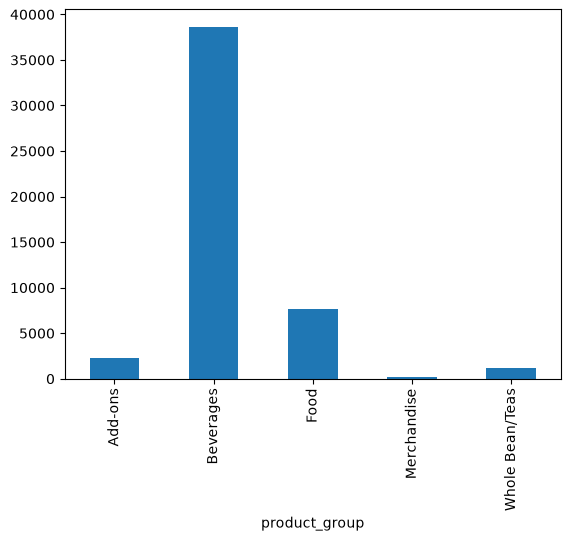

In [164]:
coffee.groupby('product_group')['transaction_date'].count().plot(kind = 'bar');


##### 27.❓Can you calculate the median profit for each product type?

In [165]:

coffee.groupby('product_type')['profit'].median().to_frame()

,profit
product_type,
Barista Espresso,3.40
Biscotti,1.22
Black tea,1.79
Brewed Black tea,3.74
Brewed Chai tea,3.74
Brewed Green tea,3.74
Brewed herbal tea,3.74
Chai tea,1.90
Clothing,19.04


##### 28.❓Create a column that shows the transaction_day



In [166]:

coffee['transaction_day']= coffee['transaction_date'].dt.day

coffee.head()

,transaction_date,transaction_time,customer_id,quantity,line_item_amount,unit_price,product_group,product_category,product_type,current_wholesale_price,customer_since,customer_birth_year,customer_generation,total_wholesale_amount,profit,profit_ratio,transaction_day
0,2019-04-01,12:04:43,558.0,1,2.5,2.5,Beverages,Tea,Brewed Chai tea,0.63,2018-06-19,1983.0,Older Millennials,0.63,1.87,3.968254,1
1,2019-04-01,11:15:38,22.0,1,2.5,2.5,Beverages,Tea,Brewed Chai tea,0.63,2017-03-03,1953.0,Baby Boomers,0.63,1.87,3.968254,1
2,2019-04-01,12:05:31,659.0,2,5.0,2.5,Beverages,Tea,Brewed Chai tea,0.63,2019-01-14,1996.0,Gen Z,1.26,3.74,3.968254,1
3,2019-04-01,16:49:38,407.0,1,2.5,2.5,Beverages,Tea,Brewed Chai tea,0.63,2017-08-11,1963.0,Baby Boomers,0.63,1.87,3.968254,1
4,2019-04-01,19:17:34,537.0,2,5.0,2.5,Beverages,Tea,Brewed Chai tea,0.63,2018-05-06,1980.0,Older Millennials,1.26,3.74,3.968254,1


##### 29.❓Is there a relationship between the day of the week and the total sale revenue? How could you explain any relationship you can see in the data?
*hint*: total sale revenue is the line_item_amount column

In [167]:
coffee['transaction_day_of_week']= coffee['transaction_date'].dt.dayofweek
coffee.groupby('transaction_day_of_week')['line_item_amount'].sum().to_frame()

#highest profit in monday(0) and lowest profit in sunday

,line_item_amount
transaction_day_of_week,
0,39692.99
1,32500.26
2,34442.58
3,31944.82
4,32326.55
5,32210.10
6,31094.25


##### 30.❓Can you make a bar chart for the previous step?

_🎨 Visualize your results 🎨_

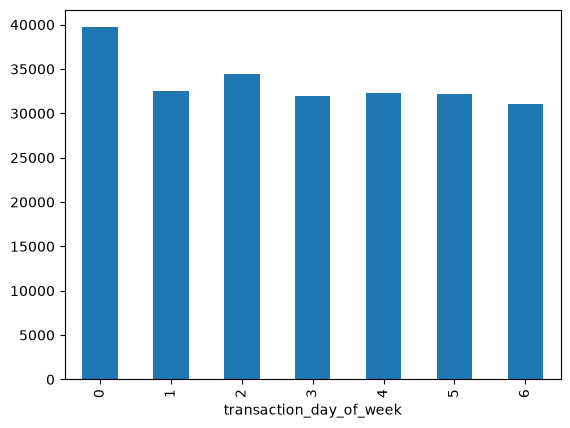

In [168]:
coffee.groupby('transaction_day_of_week')['line_item_amount'].sum().plot(kind = 'bar');



##### Write your findings here please:
👉 More transactions on Monday suggest a "back to work blues" effect

##### 31.❓The client suspects that the Gen Z customer cohort spends the most. Can you test this out and confirm whether it's true or not?

In [169]:
coffee.groupby('customer_generation')['line_item_amount'].sum().sort_values(ascending = False).to_frame()


,line_item_amount
customer_generation,
unknown,119657.67
Baby Boomers,27355.89
Gen X,26764.36
Older Millennials,25215.90
Gen Z,19759.10
Younger Millennials,15458.63


##### 32.❓Prove previous step by plotting a bar chart

_🎨 Visualize your results 🎨_

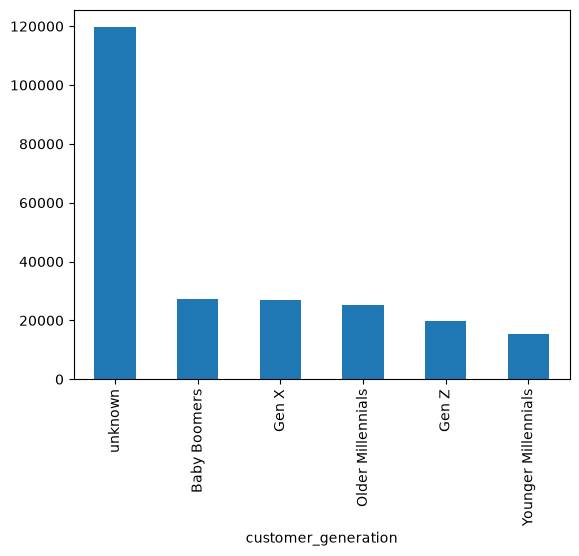

In [170]:
coffee.groupby('customer_generation')['line_item_amount'].sum().sort_values(ascending = False).plot(kind = 'bar');



##### 33.❓ Is GenZ spend the most as suspected? 
##### Write your findings here please:

👉 It looks like the opposite, Gen Z spend the second lowest in total.
-- -

## Part B 
In this section explore the coffee shop data to answer the following questions : 
1. **What kinds of products type generate the most profit? show top 5 only. Plot a chart to show the result**
2. **What segment of customers generate the most profit ratio? Plot a chart to show the result**


##### 1.❓What kinds of products type generate the most profit? show top 5 only


In [172]:
coffee.groupby('product_type')['profit'].sum().sort_values(ascending = False).to_frame().head(5)


,profit
product_type,
Barista Espresso,24599.50
Brewed Chai tea,19240.00
Gourmet brewed coffee,18944.72
Brewed Black tea,11952.20
Brewed herbal tea,11835.17


##### 2.❓Plot a chart to show the above result

_🎨 Visualize your results 🎨_

<Axes: xlabel='product_type'>

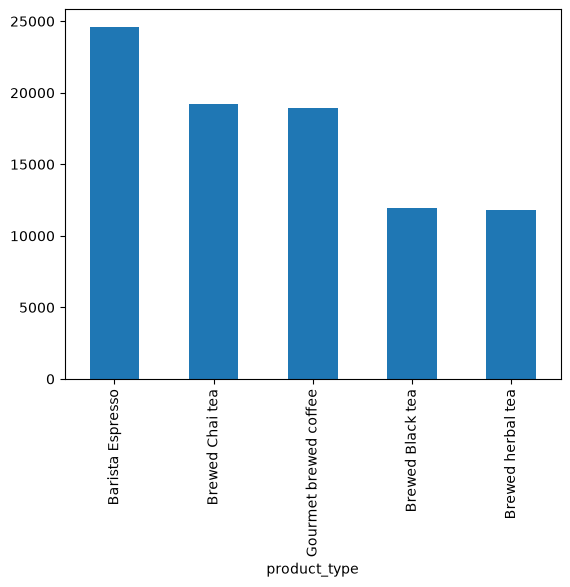

In [173]:

coffee.groupby('product_type')['profit'].sum().sort_values(ascending = False).head(5).plot(kind = 'bar')


##### 3.❓What segment of customers generate the most profit ratio? 

*Hint*: Show the average of profit ratio

In [216]:
coffee.groupby('customer_generation')['profit_ratio'].mean().sort_values(ascending = False)


customer_generation
unknown                4.649022
Baby Boomers           4.310951
Gen Z                  4.290228
Older Millennials      4.240642
Gen X                  4.226825
Younger Millennials    4.191279
Name: profit_ratio, dtype: float64

##### 4.❓Plot a chart to show the above result

_🎨 Visualize your results 🎨_

<Axes: xlabel='customer_generation'>

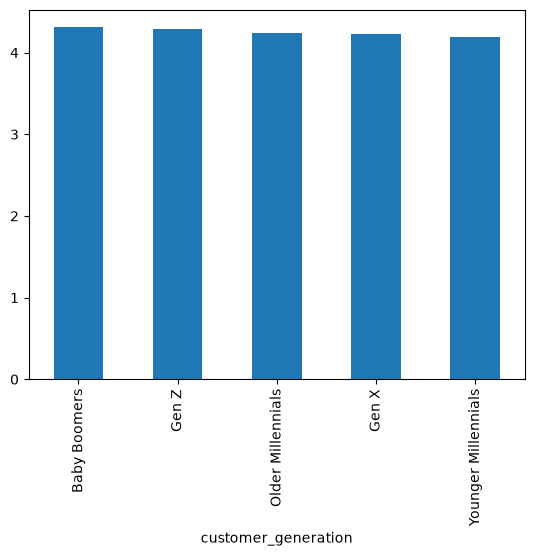

In [221]:
coffee.groupby('customer_generation')['profit_ratio'].mean().sort_values(ascending = False).tail(5).plot(kind = 'bar')





## Part C : Dig Deeper

In this section you are going to be doing your own analysis to answer this 3 main questions :
##### 1.❓Are there better or worse days/times in terms of sales? Plot a chart to show the result

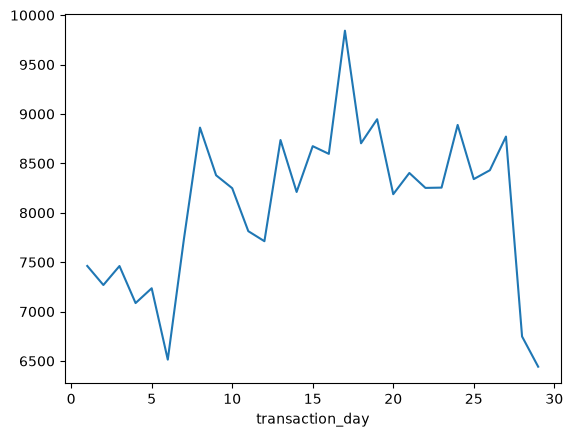

In [180]:
# Extracting dates from transaction date
coffee.groupby('transaction_day')['line_item_amount'].sum().plot();


In [191]:
# Creating time categories function to return Morning, Noon, Evenging, Night based on transaction_time
coffee.head()

def time_cat(time):
    time = pd.to_datetime(time, format='%H:%M:%S').hour
    if time >=4 and time <= 11:
        return 'Morning'
    elif time >=12 and time <= 17:
        return 'Noon'
    elif time >=18 and time <= 20:
        return 'Evenging'
    else:
        return 'Night'

# use apply to apply the time category into a new column called time_category
coffee['time_category'] = coffee['transaction_time'].apply(time_cat)
coffee.head()


,transaction_date,transaction_time,customer_id,quantity,line_item_amount,unit_price,product_group,product_category,product_type,current_wholesale_price,customer_since,customer_birth_year,customer_generation,total_wholesale_amount,profit,profit_ratio,transaction_day,transaction_day_of_week,time_category
0,2019-04-01,12:04:43,558.0,1,2.5,2.5,Beverages,Tea,Brewed Chai tea,0.63,2018-06-19,1983.0,Older Millennials,0.63,1.87,3.968254,1,0,Noon
1,2019-04-01,11:15:38,22.0,1,2.5,2.5,Beverages,Tea,Brewed Chai tea,0.63,2017-03-03,1953.0,Baby Boomers,0.63,1.87,3.968254,1,0,Morning
2,2019-04-01,12:05:31,659.0,2,5.0,2.5,Beverages,Tea,Brewed Chai tea,0.63,2019-01-14,1996.0,Gen Z,1.26,3.74,3.968254,1,0,Noon
3,2019-04-01,16:49:38,407.0,1,2.5,2.5,Beverages,Tea,Brewed Chai tea,0.63,2017-08-11,1963.0,Baby Boomers,0.63,1.87,3.968254,1,0,Noon
4,2019-04-01,19:17:34,537.0,2,5.0,2.5,Beverages,Tea,Brewed Chai tea,0.63,2018-05-06,1980.0,Older Millennials,1.26,3.74,3.968254,1,0,Evenging


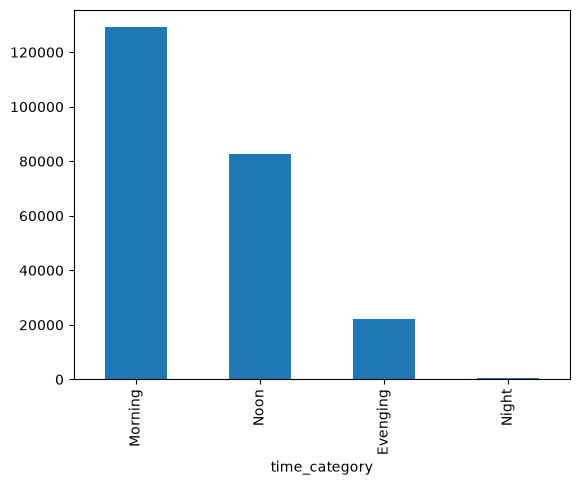

In [204]:
# Are there better or worse days/times in terms of sales?
coffee.groupby('time_category')['line_item_amount'].sum().sort_values(ascending = False).plot(kind = 'bar');
# Write your findings

> 👉 **Write Your Findings Here**: 
-- - highest sales at morning then sales start descreasing until the coffeshop is closed at night

##### 2.❓Does customers’ willingness to pay for `Beverages` product group vary by generation? Plot a chart to show the result

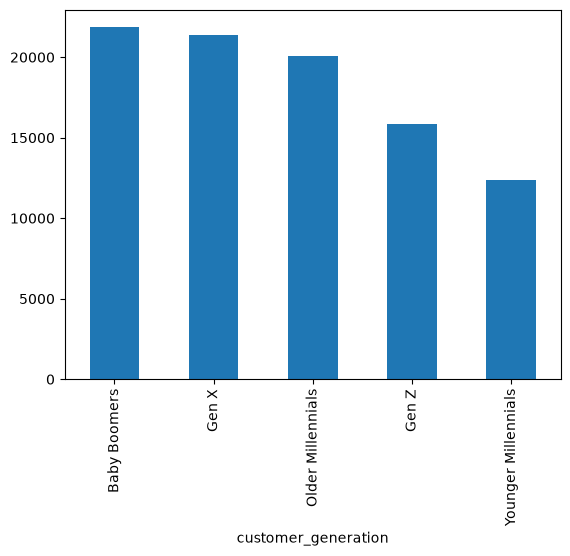

In [209]:
# Does customers’ willingness to pay for Beverages vary by generation?
coffee_b_only = coffee[
    coffee['product_group'] == 'Beverages'
]
coffee_b_only.groupby('customer_generation')['line_item_amount'].sum().sort_values(ascending = False).tail(5).plot(kind = 'bar');


# Write your findings

> 👉 **Write Your Findings Here**: 
-- - Baby Boomers pays the most for beverages

##### 3.❓Do customers who have been customers longer tend to spend more? Plot a chart to show the result (Hint : You may need to use date.today() to get todays date)

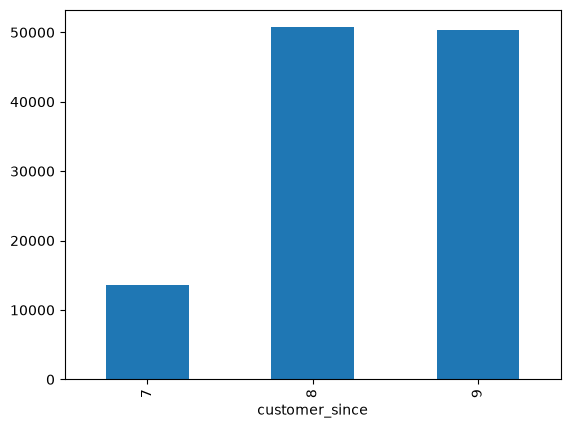

In [232]:
# Do customers who have been customers longer tend to spend more?
from datetime import datetime
current_year = datetime.now().year

coffee_l = coffee[
    coffee['customer_since'].notna()
] 
t_year = current_year - coffee_l['customer_since'].dt.year
coffee_l.groupby(t_year)['line_item_amount'].sum().plot(kind = 'bar');

In [215]:
coffee_l['customer_since'].isnull().sum()


np.int64(25042)